In [3]:
import pandas as pd

def create_dataset(path = 'C:\\Users\\lollo\\Lavoro\\Ricerca\\energiai\\dataset\\sims\\Mario_Rossi.csv',
                         train_size=0.6, val_size=0.2, test_size=0.2, timestep = 300, offset =100):

    white_list = [
        'x',
        'y',
        'bedroom',
        'livingroom',
        'kitchen',
        'bathroom',
        'elapsed_time_cumulative',
        'elapsed_time',
        'exceeds_average'  
    ]    
    
    df = pd.read_csv(path)
    df['action_group'] = (df['room'] != df['room'].shift()).cumsum()
    action_group_elapsed_time = df.groupby('action_group').agg(
        start_elapsed=('elapsed_time', 'first'),
        end_elapsed=('elapsed_time', 'last'),
        room=('room', 'first')
    )

    action_group_elapsed_time['elapsed_time_diff'] = (
        action_group_elapsed_time['end_elapsed'] - action_group_elapsed_time['start_elapsed']
    )

    action_group_elapsed_time['elapsed_time_hours'] = action_group_elapsed_time['elapsed_time_diff'] / 3600

    elapsed_time_stats = action_group_elapsed_time.groupby('room')['elapsed_time_hours'].agg(
        average='mean',
        maximum='max',
        minimum='min'
    ).reset_index()

    average_elapsed_time_by_room = elapsed_time_stats.set_index('room')['average'].to_dict()

    df['elapsed_time_cumulative'] = df.groupby('action_group')['elapsed_time'].transform(lambda x: x - x.iloc[0])

    df['exceeds_average'] = df.apply(
        lambda row: 1 if row['elapsed_time_cumulative'] / 3600 > average_elapsed_time_by_room.get(row['room'], 0) else 0,
        axis=1
    )
    interval = 60
    df['exist'] = [i % interval == 0 for i in range(len(df))]
    df = df[df['exist']]

    df = df[white_list]

    return df

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier

df = create_dataset(
    path='C:\\Users\\lollo\\Lavoro\\Ricerca\\energiai\\dataset\\sims\\Mario_Rossi.csv',
    train_size=0.6,
    val_size=0.2,
    test_size=0.2,
    timestep=300,
    offset=100
)


features = [
            # 'x',
            # 'y',
            'bedroom',
            'livingroom',
            'kitchen',
            'bathroom',
            'elapsed_time_cumulative',
            'elapsed_time'
            ]


target = [
            'bedroom',
            'livingroom',
            'kitchen',
            'bathroom',
        ]   
# features = [col for col in df.columns if col != target]

X = df[features].iloc[:-1].values
y = df[target].iloc[1:].values.argmax(axis=1)  

# Dividi il dataset in train e test
tr_size = int(.7 * len(X))
X_train, X_test, y_train, y_test = X[:tr_size], X[tr_size:], y[:tr_size], y[tr_size:]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y

# Best results
clf = DecisionTreeClassifier(min_samples_split=5,min_samples_leaf=5, max_depth=5, random_state=6)   
# clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=6)
# clf = AdaBoostClassifier(n_estimators=10, random_state=6)   


# clf = GradientBoostingClassifier(n_estimators=1000, random_state=42)   
# clf = MLPClassifier(hidden_layer_sizes=(100,),  random_state=42, solver='lbfgs')   
# clf = SVC(gamma='scale', random_state=42)   
# clf = KNeighborsClassifier(n_neighbors=1)
# clf = LogisticRegression( random_state=30)   
clf.fit(X_train, y_train)

# Valuta il modello
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       417
           1       0.92      0.92      0.92       276
           2       0.67      0.66      0.66        58
           3       0.77      0.50      0.61        60

    accuracy                           0.90       811
   macro avg       0.82      0.76      0.78       811
weighted avg       0.89      0.90      0.89       811



              precision    recall  f1-score   support

           0       0.97      0.96      0.97       417
           1       0.87      0.93      0.90       276
           2       0.63      0.67      0.65        58
           3       0.77      0.55      0.64        60

    accuracy                           0.90       811
   macro avg       0.81      0.78      0.79       811
weighted avg       0.90      0.90      0.90       811

Confusion Matrix:
 [[401   6   7   3]
 [  2 257  12   5]
 [  9   8  39   2]
 [  0  23   4  33]]


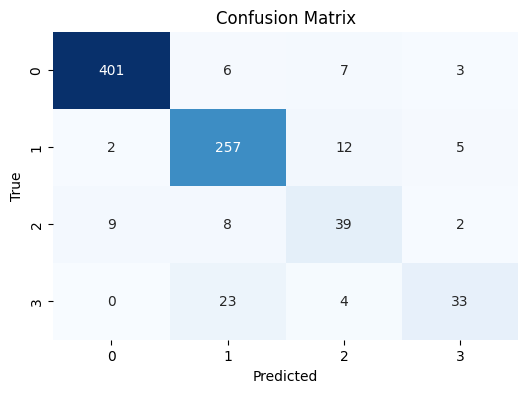

In [148]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Valuta il modello
y_pred = clf.predict(X_test)

# Stampa il classification report
print(classification_report(y_test, y_pred))

# Calcola la matrice di confusione
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualizza la matrice di confusione con una heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()